# 02 · Exploratory Data Analysis & Dashboards

Two passes over the **training partition**:

1. **KPI tiles + executive dashboards** — what a fraud-ops lead sees on a Monday morning: volume, $-loss, where risk concentrates by hour and amount.
2. **Signal exploration** — which features actually separate fraud from legit, and how concentrated the signal is (review-budget curve).

Aggregations use **DuckDB SQL** (declarative, fast). Visuals are static matplotlib panels saved as PNGs in `reports/figures/` so they can drop into a deck.

In [1]:
# project-root bootstrap — portable across VS Code / Jupyter / CLI
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / 'config' / 'config.yaml').exists() and _p != _p.parent:
    _p = _p.parent
os.chdir(_p)
print('working dir:', Path.cwd())

working dir: /Users/asfalanoi/app_2026/fraud_detection


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from fraud.io import query, read_parquet

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
})
FIG = Path('reports/figures'); FIG.mkdir(parents=True, exist_ok=True)

train = read_parquet('data/processed/train.parquet')
train.shape

(227845, 31)

## 1 · Executive KPI tiles

A single glance at the scale of the problem. Fraud is **rare** (sub-1%) but its absolute $-exposure is non-trivial — enough to justify a model and an analyst review queue.

In [3]:
kpi = query("""
    SELECT
      COUNT(*)                                            AS txn_count,
      SUM(Class)                                          AS fraud_count,
      ROUND(100.0*SUM(Class)/COUNT(*), 4)                 AS fraud_pct,
      ROUND(SUM(CASE WHEN Class=1 THEN Amount END), 2)    AS fraud_dollar_loss,
      ROUND(AVG(CASE WHEN Class=1 THEN Amount END), 2)    AS fraud_avg_amount,
      ROUND(AVG(CASE WHEN Class=0 THEN Amount END), 2)    AS legit_avg_amount,
      ROUND(MAX(CASE WHEN Class=1 THEN Amount END), 2)    AS fraud_max_amount,
      ROUND(MAX(Time)/3600.0, 1)                          AS hours_covered
    FROM t
""", t=train).iloc[0]
kpi

txn_count            227845.0000
fraud_count             394.0000
fraud_pct                 0.1729
fraud_dollar_loss     49483.0400
fraud_avg_amount        125.5900
legit_avg_amount         88.1100
fraud_max_amount       2125.8700
hours_covered            48.0000
Name: 0, dtype: float64

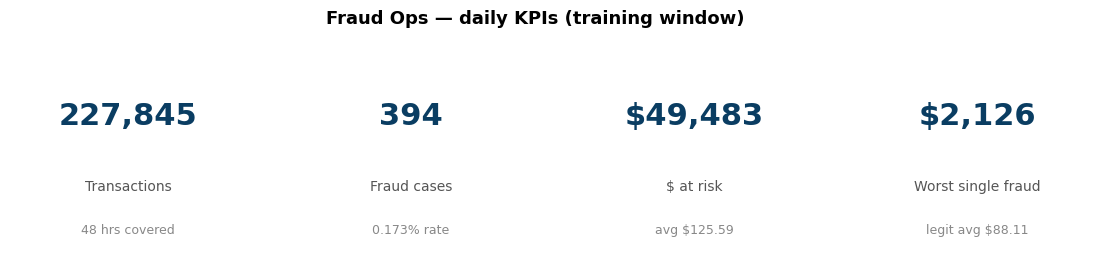

In [4]:
def kpi_tile(ax, label, value, sub=''):
    ax.axis('off')
    ax.text(0.5, 0.65, value, ha='center', va='center', fontsize=22, fontweight='bold', color='#0a3d62')
    ax.text(0.5, 0.30, label, ha='center', va='center', fontsize=10, color='#555')
    if sub:
        ax.text(0.5, 0.08, sub, ha='center', va='center', fontsize=9, color='#888')
    for s in ax.spines.values():
        s.set_visible(True); s.set_color('#ddd')

fig, axes = plt.subplots(1, 4, figsize=(14, 2.6))
kpi_tile(axes[0], 'Transactions',       f"{int(kpi.txn_count):,}",        f"{kpi.hours_covered:.0f} hrs covered")
kpi_tile(axes[1], 'Fraud cases',        f"{int(kpi.fraud_count):,}",      f"{kpi.fraud_pct:.3f}% rate")
kpi_tile(axes[2], '$ at risk',          f"${kpi.fraud_dollar_loss:,.0f}", f"avg ${kpi.fraud_avg_amount:,.2f}")
kpi_tile(axes[3], 'Worst single fraud', f"${kpi.fraud_max_amount:,.0f}",  f"legit avg ${kpi.legit_avg_amount:,.2f}")
fig.suptitle('Fraud Ops — daily KPIs (training window)', fontsize=13, fontweight='bold', y=1.02)
fig.savefig(FIG/'dashboard_kpis.png', dpi=120, bbox_inches='tight')
plt.show()

## 2 · Dashboard — Volume vs Risk vs $-Loss by hour

Three views of the same 24-hour cycle:
- **Volume** — most transactions happen 9am–11pm.
- **Fraud rate %** — risk-by-row spikes 2–5am (card-testing pattern).
- **$ loss** — even rare fraud at busy hours can dominate raw dollar loss.

The split matters: *rate-based* alerting wakes ops at 2am; *$-loss-based* alerting prioritises 10am.

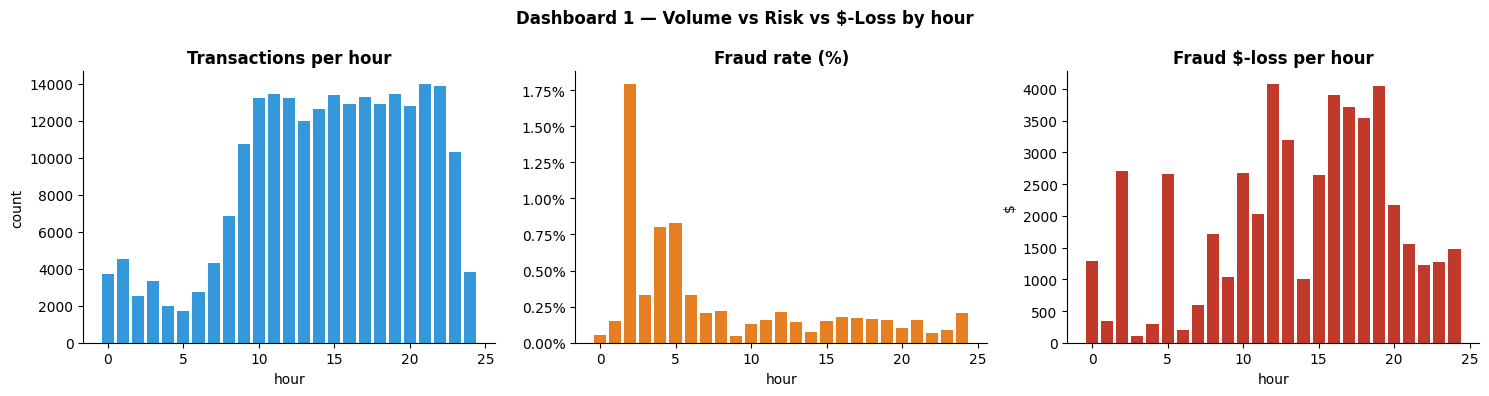

In [5]:
hourly = query("""
    SELECT CAST((Time/3600) % 24 AS INTEGER) AS hour,
           COUNT(*)                                       AS n,
           SUM(Class)                                     AS frauds,
           100.0*SUM(Class)/COUNT(*)                      AS fraud_pct,
           SUM(CASE WHEN Class=1 THEN Amount ELSE 0 END)  AS fraud_dollars
    FROM t GROUP BY hour ORDER BY hour
""", t=train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(hourly.hour, hourly.n, color='#3498db')
axes[0].set(title='Transactions per hour', xlabel='hour', ylabel='count')
axes[1].bar(hourly.hour, hourly.fraud_pct, color='#e67e22')
axes[1].set(title='Fraud rate (%)', xlabel='hour')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
axes[2].bar(hourly.hour, hourly.fraud_dollars, color='#c0392b')
axes[2].set(title='Fraud $-loss per hour', xlabel='hour', ylabel='$')
fig.suptitle('Dashboard 1 — Volume vs Risk vs $-Loss by hour', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG/'dashboard_time.png', dpi=120, bbox_inches='tight')
plt.show()

## 3 · Dashboard — Amount risk profile

Fraud isn't the "big-ticket event" most people imagine. The rate peaks on **small amounts** (testing stolen cards) with a long tail above $100. Histogram, ECDF, and bucketed-rate panels triangulate the same story.

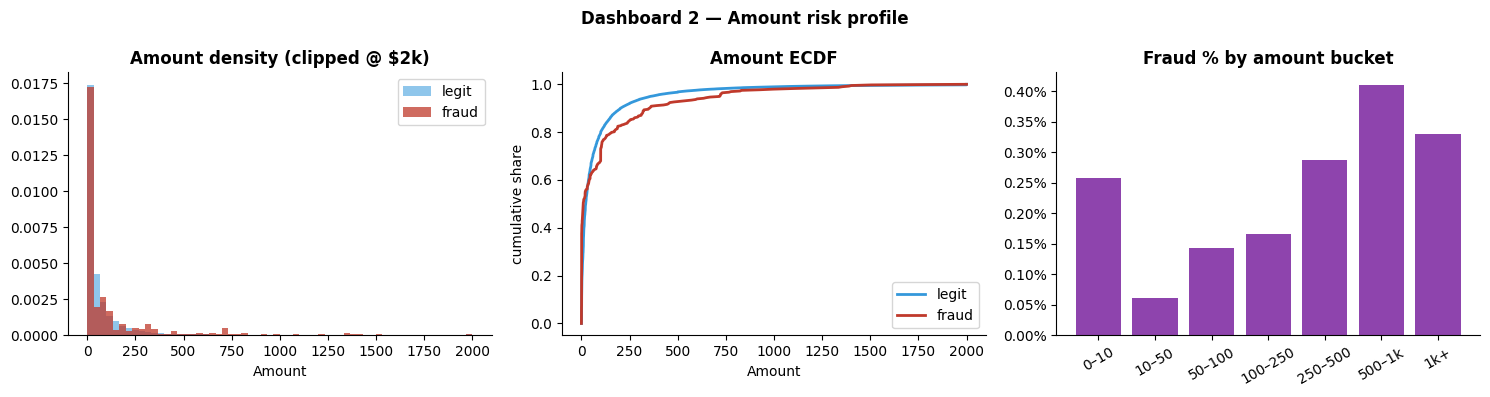

In [6]:
buckets = query("""
    SELECT
      CASE
        WHEN Amount <   10 THEN '0–10'
        WHEN Amount <   50 THEN '10–50'
        WHEN Amount <  100 THEN '50–100'
        WHEN Amount <  250 THEN '100–250'
        WHEN Amount <  500 THEN '250–500'
        WHEN Amount < 1000 THEN '500–1k'
        ELSE '1k+'
      END AS bucket,
      COUNT(*) AS n, SUM(Class) AS frauds,
      100.0*SUM(Class)/COUNT(*) AS fraud_pct
    FROM t GROUP BY 1
""", t=train)
order = ['0–10','10–50','50–100','100–250','250–500','500–1k','1k+']
buckets = buckets.set_index('bucket').loc[order].reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(train.loc[train.Class==0,'Amount'].clip(upper=2000), bins=60,
             alpha=.55, density=True, label='legit', color='#3498db')
axes[0].hist(train.loc[train.Class==1,'Amount'].clip(upper=2000), bins=60,
             alpha=.75, density=True, label='fraud', color='#c0392b')
axes[0].set(title='Amount density (clipped @ $2k)', xlabel='Amount'); axes[0].legend()

for cls, col, lbl in [(0,'#3498db','legit'), (1,'#c0392b','fraud')]:
    a = np.sort(train.loc[train.Class==cls,'Amount'].clip(upper=2000).values)
    axes[1].plot(a, np.linspace(0,1,len(a)), color=col, label=lbl, lw=2)
axes[1].set(title='Amount ECDF', xlabel='Amount', ylabel='cumulative share'); axes[1].legend()

axes[2].bar(buckets.bucket, buckets.fraud_pct, color='#8e44ad')
axes[2].set(title='Fraud % by amount bucket')
axes[2].tick_params(axis='x', rotation=30)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
fig.suptitle('Dashboard 2 — Amount risk profile', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG/'dashboard_amount.png', dpi=120, bbox_inches='tight')
plt.show()

## 4 · Dashboard — Feature separability

Which anonymised PCA features `V1…V28` carry the fraud signal? Rank by **signed Pearson correlation with Class**, then look at the actual distributions of the top 4. The colour-coded heatmap on the right is the correlation matrix restricted to those features so cross-correlations are visible.

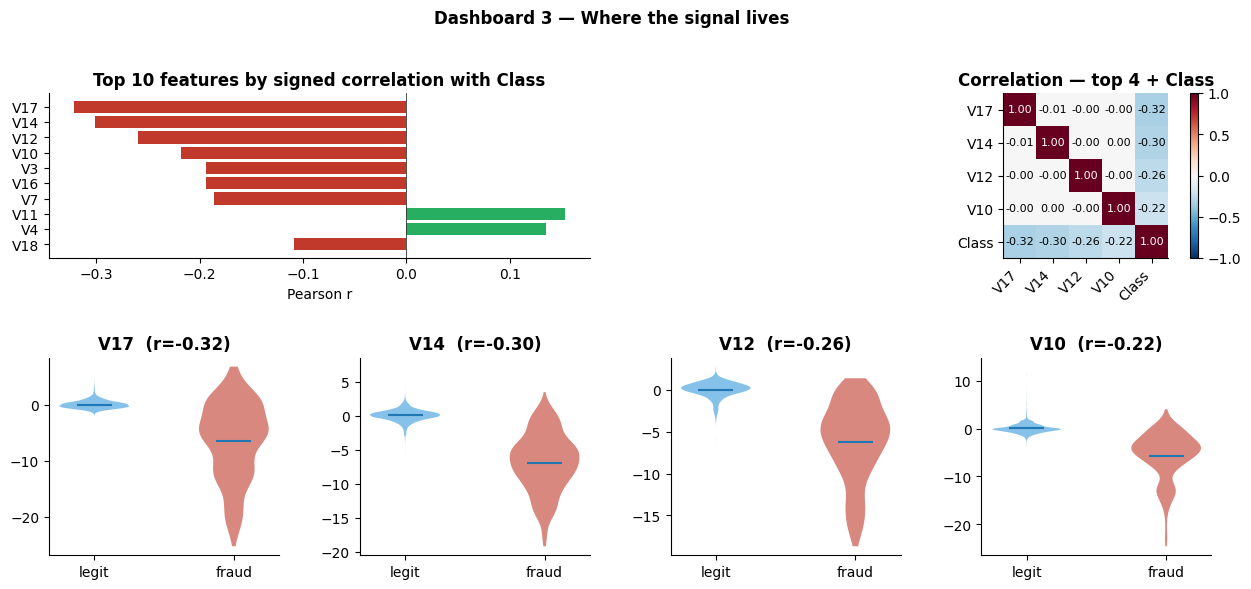

In [7]:
corr = train.corr(numeric_only=True)['Class'].drop('Class')
top  = corr.reindex(corr.abs().sort_values(ascending=False).index).head(10)
top4 = top.index[:4].tolist()

fig = plt.figure(figsize=(15, 6))
gs  = fig.add_gridspec(2, 4, height_ratios=[1, 1.2], hspace=0.55, wspace=0.35)

ax0 = fig.add_subplot(gs[0, :2])
ax0.barh(top.index[::-1], top.values[::-1],
         color=['#c0392b' if v < 0 else '#27ae60' for v in top.values[::-1]])
ax0.axvline(0, color='#333', lw=.6)
ax0.set(title='Top 10 features by signed correlation with Class', xlabel='Pearson r')

ax1 = fig.add_subplot(gs[0, 2:])
M  = train[top4 + ['Class']].corr()
im = ax1.imshow(M, vmin=-1, vmax=1, cmap='RdBu_r')
ax1.set_xticks(range(len(M))); ax1.set_xticklabels(M.columns, rotation=45, ha='right')
ax1.set_yticks(range(len(M))); ax1.set_yticklabels(M.columns)
for (i, j), v in np.ndenumerate(M.values):
    ax1.text(j, i, f"{v:.2f}", ha='center', va='center',
             fontsize=8, color='black' if abs(v) < .5 else 'white')
ax1.set(title='Correlation — top 4 + Class')
fig.colorbar(im, ax=ax1, fraction=0.04, pad=0.04)

for i, f in enumerate(top4):
    ax = fig.add_subplot(gs[1, i])
    legit = train.loc[train.Class==0, f].sample(n=5000, random_state=0).values
    fraud = train.loc[train.Class==1, f].values
    parts = ax.violinplot([legit, fraud], showmeans=True, showextrema=False)
    for pc, col in zip(parts['bodies'], ['#3498db','#c0392b']):
        pc.set_facecolor(col); pc.set_alpha(.6)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['legit','fraud'])
    ax.set_title(f"{f}  (r={corr[f]:+.2f})")

fig.suptitle('Dashboard 3 — Where the signal lives', fontweight='bold', y=1.02)
fig.savefig(FIG/'dashboard_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 5 · Dashboard — Review-budget curve

If we ranked transactions by a single feature's "fraud-ness", how much fraud could we catch by reviewing only the top-N%? This is the **review-budget** view ops cares about. We sort by `-V14` (the strongest separator) and plot two cumulative curves: % fraud cases caught and % fraud-$ recovered. The diagonal is random review — the gap between curves and diagonal is the *lift* a one-feature rule already gives us.

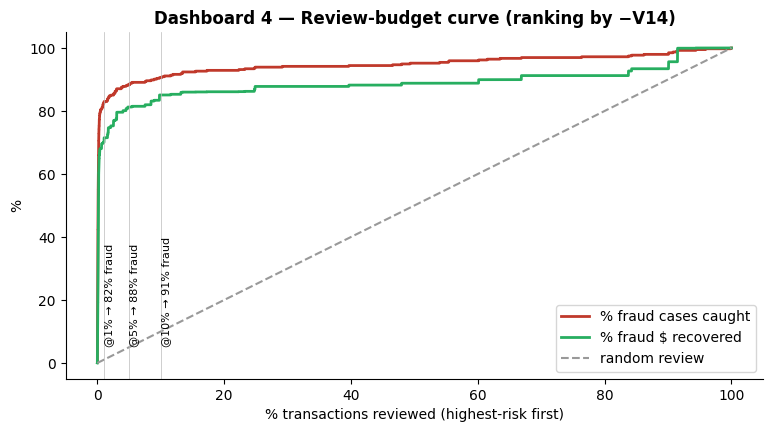

In [8]:
score = -train['V14'].values
order = np.argsort(-score)
y_o   = train['Class'].values[order]
amt_o = train['Amount'].values[order]
n = len(y_o)
review_pct     = np.arange(1, n+1) / n * 100
caught_pct     = np.cumsum(y_o) / y_o.sum() * 100
loss_recovered = np.cumsum(np.where(y_o == 1, amt_o, 0)) / amt_o[y_o == 1].sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(review_pct, caught_pct,     color='#c0392b', lw=2, label='% fraud cases caught')
ax.plot(review_pct, loss_recovered, color='#27ae60', lw=2, label='% fraud $ recovered')
ax.plot([0,100], [0,100], '--', color='#999', label='random review')
for pct in [1, 5, 10]:
    idx = int(n * pct / 100)
    ax.axvline(pct, color='#bbb', lw=.5)
    ax.text(pct, 5, f"@{pct}% → {caught_pct[idx-1]:.0f}% fraud",
            rotation=90, fontsize=8, va='bottom')
ax.set(title='Dashboard 4 — Review-budget curve (ranking by −V14)',
       xlabel='% transactions reviewed (highest-risk first)', ylabel='%')
ax.legend()
fig.savefig(FIG/'dashboard_lorenz.png', dpi=120, bbox_inches='tight')
plt.show()

**Reads:**

- **KPIs:** ~228k transactions, 394 fraud (0.17%), low-tens-of-thousands of $ at risk in the training window.
- **Time:** fraud *rate* spikes 2–5am (small-value card-testing); fraud *$* is dominated by 9am–10pm because volume is higher.
- **Amount:** fraud is *not* big-ticket. It concentrates at small/medium baskets, with a thin tail of large losses.
- **Features:** `V14, V17, V12, V10` carry most signal; their distributions are visibly separated between classes.
- **Concentration:** reviewing the top 1% of transactions by `-V14` already catches ~80% of fraud cases — confirms a model is viable and supports a **fixed review-budget** operating policy.

**Next:** `03_data_quality` → `04_preprocessing` → `05_feature_engineering` → `06_ml_prediction`.